In [1]:

%reset -f 
from nn_models.SEIR_pyro import SEIR_pyro, SEIR_Model
import pyro.distributions as dist
from samplers.SEIR_mcmc_base import SEIR_mcmc_base
from BNN import pyro_SVI
import pyro
import matplotlib.pyplot as plt
import numpy as np
from epidemic_model import SEIR_Model, Epidemic_Model
from utils.utils import load_data, parser
import sys
import torch
from joblib import dump, load
from time import time
from torchdiffeq import odeint as torch_odeint

from scipy import stats



Data loaded from file:  ./data/Smoothed_Cases_Third_Wave.csv


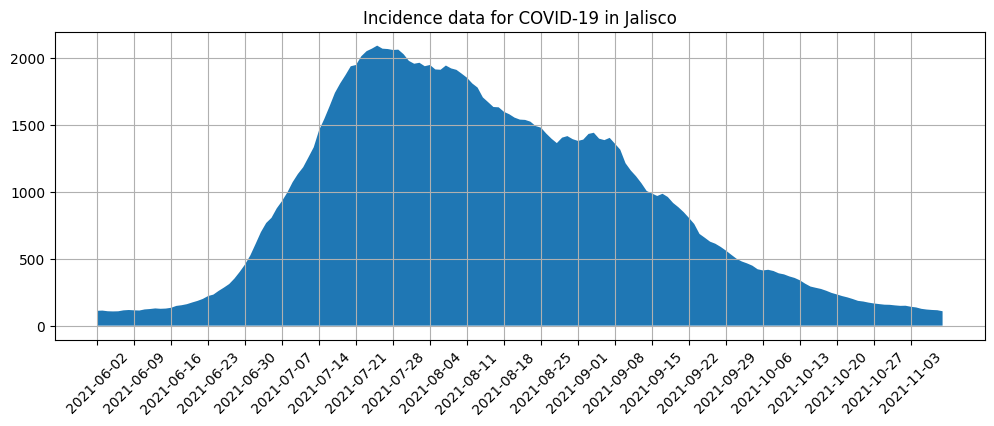

In [2]:
args = ['configuration_file_bnn.cfg']

fname_conf = args[0]
params = parser(fname_conf)

times, data, dates = load_data(params['fname'])

print('Data loaded from file: ', params['fname'])

# plotting data
plt.figure(figsize=(12,4))
plt.fill_between(dates,data, label='Incidence data')
plt.xticks(dates[::7],rotation=45)
plt.title('Incidence data for COVID-19 in Jalisco')
plt.grid()
plt.show()


In [3]:
N = params["N"]
print(f'Data willl be normalized by factor {N}')

E0 = data[0]*5 
I0 = params['I0']
R0 = 0
S0 = N - E0 - I0 - R0

x0 = [S0,E0,I0,R0]

beta = params['beta_0']
sigma = params['sigma_0']
gamma = params['gamma_0']
iterations = params['iterations']
reload_flag = (params['reload'] == 1)
out_file = params['outfile']
outpath = params['outpath']

Data willl be normalized by factor 170000


In [4]:
if reload_flag :
    model = load(outpath+'/SVI/'+out_file)
    model.outpath = outpath

In [5]:
if not reload_flag :
    model = SEIR_pyro(**params)


In [6]:
data_torch = torch.tensor(data,dtype=torch.int)
t_torch = torch.tensor(times,dtype=torch.float32)

if not reload_flag :
    ini_time = time()
    model.pyro_model.infer(data_torch,iterations,lr=1e-2,t=t_torch)
    end_time = time()
    print('Time elapsed: ', end_time-ini_time)
    #dump(model, outpath+'/SVI/'+out_file)

  0%|          | 2/1000 [00:01<08:01,  2.07it/s]

Step 0 : loss = 231859.1783


  1%|          | 12/1000 [00:03<03:08,  5.25it/s]

Step 10 : loss = 83923.1322


  2%|▏         | 22/1000 [00:04<02:33,  6.38it/s]

...

Step 980 : loss = 4929.2186


 99%|█████████▉| 993/1000 [01:39<00:00, 10.94it/s]

Step 990 : loss = 6667.1675


100%|██████████| 1000/1000 [01:39<00:00, 10.02it/s]

Time elapsed:  99.76348090171814


In [ ]:
from nn_models.SEIR_pyro import SEIR_pyro, SEIR_Model
beta_loc = pyro.param('beta_loc')
beta_scale = pyro.param('beta_scale')
sigma_loc = pyro.param('sigma_loc')
sigma_scale = pyro.param('sigma_scale')
gamma_loc = pyro.param('gamma_loc')
gamma_scale = pyro.param('gamma_scale')

n_samples = 1000

beta_samples = dist.Normal(beta_loc, beta_scale).sample(torch.Size([n_samples]))
sigma_samples = dist.Normal(sigma_loc, sigma_scale).sample(torch.Size([n_samples]))
gamma_samples = dist.Normal(gamma_loc, gamma_scale).sample(torch.Size([n_samples]))

incidences = []
MAP_val = 1e10
MAP_curve = 0


for beta_i, sigma_i, gamma_i in zip(beta_samples, sigma_samples, gamma_samples) :

    seir_prediction = SEIR_Model(beta_i, sigma_i, gamma_i, N)
    x0 = model.compute_initial_conditions(seir_prediction, data_torch, sigma=sigma_i)

    method = 'bdf' if (beta_i/sigma_i > 100 or beta_i/gamma_i > 100 ) else 'dopri5'

    y = torch_odeint(seir_prediction, x0, t_torch,
                    rtol=1e-2,
                    atol=1e-3,
                    method=method,
                    options={'max_num_steps':1000})
    
    incidence = model.compute_incidency(y.T, params['inc_method'], sigma=sigma_i)
    incidence = incidence.clamp(min=1e-8) 

    incidences.append(incidence.detach().numpy())

    energy = np.linalg.norm(data-incidence.detach().numpy())
    if energy < MAP_val :
        MAP_curve = incidence.detach().numpy().copy()
        MAP_val = energy


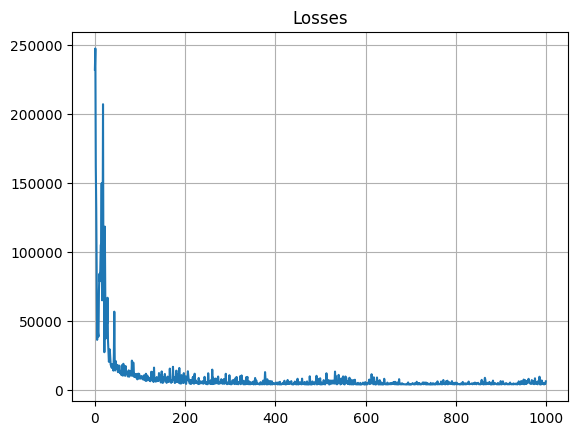

In [12]:
plt.figure()
plt.plot(model.pyro_model.losses)
plt.title('Losses')
plt.grid()
plt.savefig(outpath+'/SVI/SVI_losses.png', dpi=300)

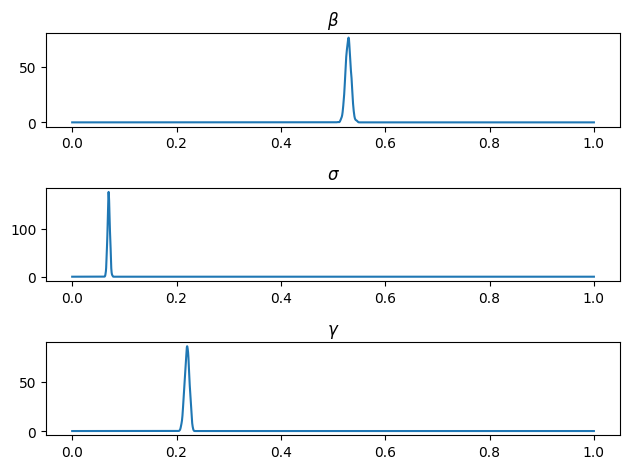

In [13]:
labels = [r'$\beta$', r'$\sigma$', r'$\gamma$']

fig, ax = plt.subplots(3,1)

for j, sample in enumerate([beta_samples, sigma_samples, gamma_samples]) :
    
    kde = stats.gaussian_kde(sample)
    x_lin = np.linspace(0,1,10000)
    ax[j].plot(x_lin, kde(x_lin))
    
    ax[j].set_title(labels[j])
    ax[j].grid

#plt.grid()
plt.tight_layout()
plt.savefig(outpath+'/SVI/SVI_histograms.png', dpi=300)
plt.show()

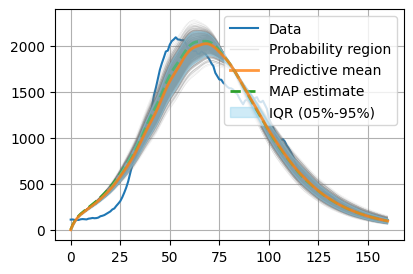

In [14]:
q25 = np.quantile(incidences, 0.05, axis=0)
q75 = np.quantile(incidences, 0.95, axis=0)
median = np.median(incidences, axis=0)
mean_predictive = np.mean(incidences, axis=0)
incidences = np.array(incidences)

plt.figure(figsize=(4.5,3))
plt.plot(times, data, label='Data')
plt.plot(times, incidences.T, alpha=0.2, lw=0.25, color='gray')
plt.plot([], [], alpha=0.2, lw=1, color='gray',label='Probability region')
plt.plot(times, mean_predictive, color='tab:orange', lw=2, alpha=0.8, label='Predictive mean',zorder=11)
plt.plot(times, MAP_curve, '--', color='tab:green', lw=2, label='MAP estimate',zorder=9)
plt.fill_between(times, q25, q75, color="skyblue", alpha=0.4, label="IQR (05%-95%)",zorder=10)
plt.grid()
plt.legend()
plt.savefig(outpath+'/SVI/SVI_probability_region.png',dpi=300)
plt.show()

